# M1 — Step 1: Explore the collar data and cut it into windows

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I
**Dataset:** Kamminga et al., goat collar inertial recordings (G1–G4)

---

## What this notebook is for

The four M1 model notebooks (Random Forest, 1D CNN, LSTM, CNN-LSTM) all need
**exactly the same** training data, cut the same way and split the same way.
If each notebook cut its own windows, the models would not be comparable and
your "why we chose this model" argument would fall apart.

So this notebook does the cutting **once** and saves the result. Every model
notebook then loads that one file.

It does five things:

1. Loads G1–G4 and reports what is actually inside them.
2. Confirms the sampling rate is 200 Hz.
3. Plots one example of each activity so you can see the signals.
4. Cuts the stream into 2-second windows that **never cross a segment**.
5. Splits into train / validation / test **by segment**, and saves everything.

**Run order:** Kernel → Restart Kernel and Run All Cells. The cells depend on
each other, so running them out of order gives `NameError`.

In [1]:
# =============================================================================
# CONFIGURATION  --  the only cell you may need to edit
# =============================================================================

# The folder that contains G1.csv, G2.csv, G3.csv, G4.csv
DATA_DIR = r"C:\Users\OKEDI\Desktop\Goat Collar Readings"

# Where the windowed data and figures get written
OUT_DIR = "outputs_kamminga"

# ---- Signal settings --------------------------------------------------------
# The collar samples every 5 ms, so 200 readings per second.
SAMPLE_RATE_HZ = 200

# A goat chewing a mouthful takes roughly a second. Two seconds gives the model
# a whole chew cycle plus context, without blurring two activities together.
WINDOW_SECONDS = 2.0

# 50% overlap: each window starts halfway through the previous one. This
# doubles the number of training examples without inventing any new data.
OVERLAP = 0.5

# Which sensor channels to use.
#   ax ay az  = accelerometer  (low-g, the useful one)
#   gx gy gz  = gyroscope      (rotation - head swings while browsing)
# Deliberately NOT used:
#   axhg ayhg azhg = high-g impact sensor, saturates and adds noise
#   cx cy cz       = magnetometer, only recorded on alternate rows (NaN gaps)
#   pressure       = mostly NaN
#   temp           = body/ambient temperature, not a movement signal
CHANNELS = ["ax", "ay", "az", "gx", "gy", "gz"]

# ---- Split settings ---------------------------------------------------------
# Fractions of SEGMENTS (not rows, not windows) going to each split.
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
# test gets the rest

RANDOM_SEED = 42


### Why these choices matter for your report

**Window length.** Too short and the model sees a fragment of a chew and cannot
tell eating from head-shaking. Too long and a two-second browse gets buried
inside a ten-second window of walking. Two seconds is the standard choice in
the animal-activity literature and it matches the goat's chew rhythm.

**Overlap.** Overlap is free extra training data — but it is also the single
biggest leakage trap in this kind of project. Two overlapping windows share
half their samples. If one lands in training and the other in testing, the
model has effectively seen the test set. That is why the split below is done on
**segments**, before any window is cut.

**Dropped channels.** Say this out loud in your defence: you did not use every
column just because it was there. The magnetometer is NaN on alternate rows,
the high-g sensor is for impacts not gait, and pressure is nearly empty.

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(OUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("output dir ", os.path.abspath(OUT_DIR))


numpy       2.4.2
pandas      3.0.1
output dir  c:\Users\OKEDI\Downloads\outputs_kamminga


In [3]:
# =============================================================================
# FIND THE CSV FILES
# =============================================================================
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"DATA_DIR does not exist:\n  {DATA_DIR}\n\n"
        "Open File Explorer, go to the folder holding G1.csv, click the address "
        "bar, copy the path, and paste it into DATA_DIR above "
        "(keep the r before the quote)."
    )

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, "G*.csv")))

print(f"Looking in: {DATA_DIR}\n")
if not csv_paths:
    print("No G*.csv files found directly here. What IS here:")
    for name in sorted(os.listdir(DATA_DIR))[:40]:
        marker = "[dir] " if os.path.isdir(os.path.join(DATA_DIR, name)) else "      "
        print("  ", marker, name)
    raise FileNotFoundError("Could not find G1.csv ... G4.csv in DATA_DIR.")

for p in csv_paths:
    size_mb = os.path.getsize(p) / 1e6
    print(f"  {os.path.basename(p):12s}  {size_mb:8.1f} MB")
print(f"\n{len(csv_paths)} file(s) found.")


Looking in: C:\Users\OKEDI\Desktop\Goat Collar Readings

  G1.csv           266.9 MB
  G2.csv           263.6 MB
  G3.csv           238.8 MB
  G4.csv           305.2 MB

4 file(s) found.


In [4]:
# =============================================================================
# LOAD THE DATA
# =============================================================================
# These files are large. We read only the columns we need, which cuts both the
# load time and the memory use by more than half.
NEEDED = ["label", "animal_ID", "segment_ID", "timestamp_ms"] + CHANNELS

frames = []
for p in csv_paths:
    df_one = pd.read_csv(p, usecols=lambda c: c in NEEDED)
    missing = [c for c in NEEDED if c not in df_one.columns]
    if missing:
        raise ValueError(f"{os.path.basename(p)} is missing columns: {missing}")
    df_one["source_file"] = os.path.basename(p)
    frames.append(df_one)
    print(f"  loaded {os.path.basename(p):12s}  {len(df_one):>10,} rows")

df = pd.concat(frames, ignore_index=True)
del frames

print(f"\nTotal: {len(df):,} rows, {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()


  loaded G1.csv         2,116,944 rows
  loaded G2.csv         2,056,530 rows
  loaded G3.csv         2,245,625 rows
  loaded G4.csv         2,393,454 rows

Total: 8,812,553 rows, 11 columns
Memory: 1994.8 MB


,label,animal_ID,segment_ID,timestamp_ms,ax,ay,az,gx,gy,gz,source_file
0,walking,G1,1,1,1.57538,4.34787,-9.27514,10.54880,-28.4756,91.9512,G1.csv
1,walking,G1,1,6,1.47962,4.30477,-9.31105,9.51220,-27.0732,88.1707,G1.csv
2,walking,G1,1,11,1.36469,4.24492,-9.42118,9.57317,-25.2439,83.9634,G1.csv
3,walking,G1,1,16,1.21386,4.22816,-9.59835,11.21950,-22.9878,79.2683,G1.csv
4,walking,G1,1,21,1.07021,4.29520,-9.67257,13.47560,-19.8780,73.8415,G1.csv


In [5]:
# =============================================================================
# WHAT ACTIVITIES ARE IN HERE?
# =============================================================================
label_counts = df["label"].value_counts()
total = len(df)

print(f"{'activity':<22} {'rows':>12} {'share':>8} {'seconds':>10}")
print("-" * 56)
for lab, n in label_counts.items():
    print(f"{str(lab):<22} {n:>12,} {n/total:>7.1%} {n/SAMPLE_RATE_HZ:>10,.0f}")
print("-" * 56)
print(f"{'TOTAL':<22} {total:>12,} {1.0:>7.1%} {total/SAMPLE_RATE_HZ:>10,.0f}")
print(f"\nThat is {total/SAMPLE_RATE_HZ/3600:.1f} hours of collar recording.")


activity                       rows    share    seconds
--------------------------------------------------------
standing                  4,215,519   47.8%     21,078
grazing                   1,662,497   18.9%      8,312
walking                   1,487,928   16.9%      7,440
lying                       984,396   11.2%      4,922
trotting                    171,602    1.9%        858
running                     111,346    1.3%        557
scratch_biting               92,715    1.1%        464
fighting                     72,857    0.8%        364
shaking                      13,693    0.2%         68
--------------------------------------------------------
TOTAL                     8,812,553  100.0%     44,063

That is 12.2 hours of collar recording.


In [6]:
# =============================================================================
# ANIMALS AND SEGMENTS
# =============================================================================
print("Rows per animal:")
print(df["animal_ID"].value_counts().to_string())

# A segment is one continuous uninterrupted bout of one activity on one animal.
# segment_ID restarts per file, so the real identity of a segment is the PAIR
# (animal_ID, segment_ID). We build one string key for it now and use that key
# everywhere afterwards.
df["seg_key"] = df["animal_ID"].astype(str) + "_s" + df["segment_ID"].astype(str)

n_segments = df["seg_key"].nunique()
print(f"\nUnique segments: {n_segments:,}")

seg_info = (df.groupby("seg_key")
              .agg(animal=("animal_ID", "first"),
                   label=("label", "first"),
                   n_rows=("label", "size"),
                   n_labels=("label", "nunique"))
              .reset_index())
seg_info["seconds"] = seg_info["n_rows"] / SAMPLE_RATE_HZ

# Sanity check: a segment should contain exactly one activity.
mixed = (seg_info["n_labels"] > 1).sum()
print(f"Segments containing more than one activity: {mixed}")
if mixed:
    print("  -> segment_ID is reused across activities; the seg_key will be")
    print("     rebuilt to include the label so that windows stay pure.")

print("\nSegment length (seconds):")
print(seg_info["seconds"].describe().to_string())

print("\nSegments per activity:")
print(seg_info["label"].value_counts().to_string())


Rows per animal:
animal_ID
G4    2393454
G3    2245625
G1    2116944
G2    2056530

Unique segments: 2,923
Segments containing more than one activity: 0

Segment length (seconds):
count    2923.000000
mean       15.074501
std        45.227550
min         0.065000
25%         3.077500
50%         5.360000
75%        11.195000
max      1080.795000

Segments per activity:
label
walking           1064
standing          1048
trotting           266
grazing            152
running            135
scratch_biting     103
fighting            79
shaking             59
lying               17


In [7]:
# =============================================================================
# REPAIR THE SEGMENT KEY IF NEEDED
# =============================================================================
# If any segment_ID covered more than one activity, the ID alone is not a safe
# unit. Adding the label to the key splits those into pure pieces.
if mixed:
    df["seg_key"] = (df["animal_ID"].astype(str)
                     + "_s" + df["segment_ID"].astype(str)
                     + "_" + df["label"].astype(str))
    seg_info = (df.groupby("seg_key")
                  .agg(animal=("animal_ID", "first"),
                       label=("label", "first"),
                       n_rows=("label", "size"))
                  .reset_index())
    seg_info["seconds"] = seg_info["n_rows"] / SAMPLE_RATE_HZ
    print(f"Rebuilt. Unique segments now: {df['seg_key'].nunique():,}")
else:
    print("Segment key is clean; no repair needed.")

print(f"\nSegments: {len(seg_info):,}")


Segment key is clean; no repair needed.

Segments: 2,923


### Read this before you go further

`segment_ID` is the most important column in the file and it is easy to miss.

A segment is **one continuous stretch of the recording during which the goat was
doing one thing**. When the observer wrote down "walking, 14:02 to 14:06", that
stretch is one segment. The samples inside a segment are 5 ms apart and are
almost identical to their neighbours.

This is why every split from here on is done **on segments, never on rows and
never on windows**. If row 4,000 goes to training and row 4,001 goes to testing,
your model scores 99% and has learned nothing. Examiners look for exactly this.

In [8]:
# =============================================================================
# CONFIRM THE SAMPLING RATE
# =============================================================================
# Take a few long segments and look at the gap between consecutive timestamps.
check_segs = seg_info.sort_values("n_rows", ascending=False)["seg_key"].head(5)

print(f"{'segment':<28} {'median gap (ms)':>16} {'implied Hz':>12}")
print("-" * 58)
for sk in check_segs:
    t = df.loc[df["seg_key"] == sk, "timestamp_ms"].to_numpy()
    gaps = np.diff(t)
    gaps = gaps[gaps > 0]
    if len(gaps) == 0:
        continue
    med = float(np.median(gaps))
    print(f"{sk:<28} {med:>16.2f} {1000.0/med:>12.1f}")
print("-" * 58)
print(f"Configured SAMPLE_RATE_HZ = {SAMPLE_RATE_HZ}")
print("\nIf the implied Hz does not match, change SAMPLE_RATE_HZ in the")
print("configuration cell and re-run from the top.")


segment                       median gap (ms)   implied Hz
----------------------------------------------------------
G4_s454                                  5.00        200.0
G2_s430                                  5.00        200.0
G2_s425                                  5.00        200.0
G4_s457                                  5.00        200.0
G3_s403                                  5.00        200.0
----------------------------------------------------------
Configured SAMPLE_RATE_HZ = 200

If the implied Hz does not match, change SAMPLE_RATE_HZ in the
configuration cell and re-run from the top.


In [9]:
# =============================================================================
# MISSING VALUES IN THE CHANNELS WE ACTUALLY USE
# =============================================================================
nan_counts = df[CHANNELS].isna().sum()
print("NaNs per channel:")
for c in CHANNELS:
    print(f"  {c:<6} {nan_counts[c]:>10,}  ({nan_counts[c]/len(df):.3%})")

before = len(df)
df = df.dropna(subset=CHANNELS).reset_index(drop=True)
print(f"\nDropped {before - len(df):,} rows with missing sensor values.")
print(f"Remaining: {len(df):,} rows")

# A tiny number of drops is harmless. If a large share disappears, one of the
# chosen channels is sparse and should be removed from CHANNELS instead.
if before - len(df) > 0.05 * before:
    print("\nWARNING: more than 5% of rows dropped. Check which channel is")
    print("sparse and consider removing it from CHANNELS.")


NaNs per channel:
  ax              0  (0.000%)
  ay              0  (0.000%)
  az              0  (0.000%)
  gx              0  (0.000%)
  gy              0  (0.000%)
  gz              0  (0.000%)

Dropped 0 rows with missing sensor values.
Remaining: 8,812,553 rows


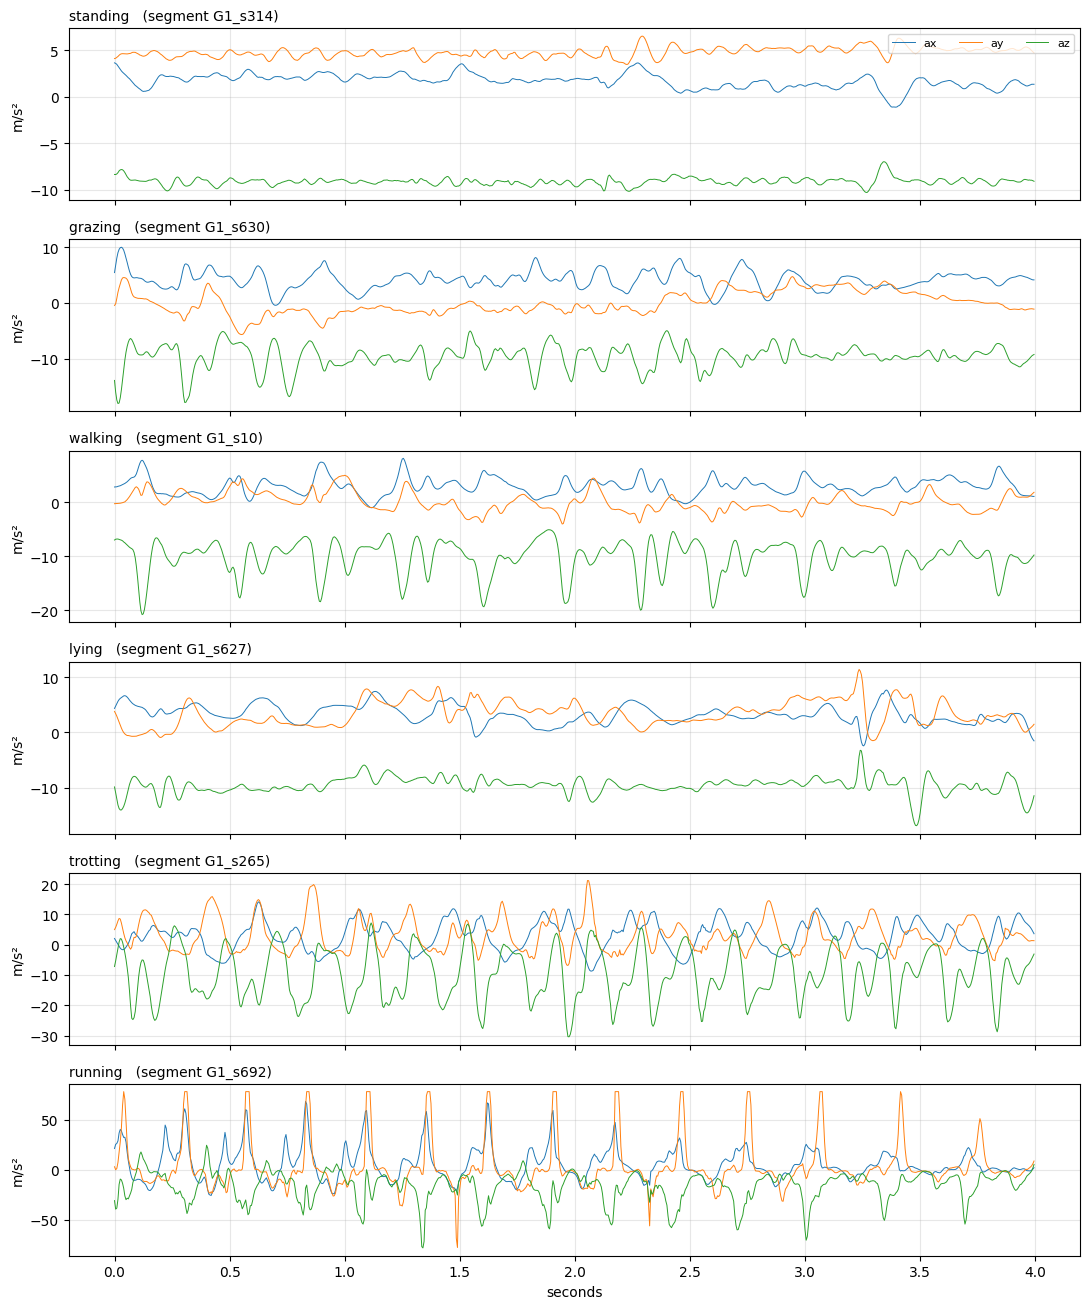

Saved: fig_signals_by_activity.png

Put this figure in your report. It is the evidence that the classes
are separable in principle, before any model is trained.


In [10]:
# =============================================================================
# LOOK AT THE SIGNALS
# =============================================================================
# One 4-second example of each activity. You want to SEE that eating looks
# different from walking before you ask a model to tell them apart.
activities = list(label_counts.index)
n_show = min(len(activities), 6)
show_samples = int(4 * SAMPLE_RATE_HZ)

fig, axes = plt.subplots(n_show, 1, figsize=(11, 2.2 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for ax, act in zip(axes, activities[:n_show]):
    seg_for_act = seg_info[(seg_info["label"] == act)
                           & (seg_info["n_rows"] >= show_samples)]
    if seg_for_act.empty:
        ax.set_title(f"{act} — no segment long enough to plot")
        continue
    sk = seg_for_act.iloc[0]["seg_key"]
    chunk = df.loc[df["seg_key"] == sk, ["ax", "ay", "az"]].head(show_samples)
    t = np.arange(len(chunk)) / SAMPLE_RATE_HZ
    ax.plot(t, chunk["ax"], linewidth=0.7, label="ax")
    ax.plot(t, chunk["ay"], linewidth=0.7, label="ay")
    ax.plot(t, chunk["az"], linewidth=0.7, label="az")
    ax.set_title(f"{act}   (segment {sk})", fontsize=10, loc="left")
    ax.set_ylabel("m/s²")
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("seconds")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig_signals_by_activity.png"), dpi=150)
plt.show()

print("Saved: fig_signals_by_activity.png")
print("\nPut this figure in your report. It is the evidence that the classes")
print("are separable in principle, before any model is trained.")


In [11]:
# =============================================================================
# DEFINE THE BINARY TARGET: IS THE GOAT EATING?
# =============================================================================
# M1 answers one question: "is the goat taking a bite right now?" — because
# that is the moment the camera should fire. Everything else is background.
#
# The activity names in this dataset are printed above. Edit the two lists
# below to match them exactly if the automatic matching gets it wrong.

EATING_KEYWORDS = ["graz", "brows", "eat", "forag", "feed"]

def is_eating(label):
    low = str(label).lower()
    return any(k in low for k in EATING_KEYWORDS)

mapping = {lab: (1 if is_eating(lab) else 0) for lab in label_counts.index}

print("Automatic mapping — CHECK THIS TABLE:")
print(f"{'activity':<22} {'-> eating?':>12}")
print("-" * 36)
for lab, v in sorted(mapping.items(), key=lambda kv: (-kv[1], str(kv[0]))):
    print(f"{str(lab):<22} {('YES' if v else 'no'):>12}")
print("-" * 36)
print("\nIf anything is mapped wrongly, edit EATING_KEYWORDS above, or")
print("override a single entry directly, for example:")
print("    mapping['ruminating'] = 0")
print("then re-run this cell and continue.")

df["y_binary"] = df["label"].map(mapping).astype(np.int8)
pos = int(df["y_binary"].sum())
print(f"\nEating rows:     {pos:>12,}  ({pos/len(df):.1%})")
print(f"Not-eating rows: {len(df)-pos:>12,}  ({1-pos/len(df):.1%})")


Automatic mapping — CHECK THIS TABLE:
activity                 -> eating?
------------------------------------
grazing                         YES
fighting                         no
lying                            no
running                          no
scratch_biting                   no
shaking                          no
standing                         no
trotting                         no
walking                          no
------------------------------------

If anything is mapped wrongly, edit EATING_KEYWORDS above, or
override a single entry directly, for example:
    mapping['ruminating'] = 0
then re-run this cell and continue.

Eating rows:        1,662,497  (18.9%)
Not-eating rows:    7,150,056  (81.1%)


**Note on rumination.** A goat chewing cud looks a lot like a goat chewing a
leaf, but the camera must *not* fire during rumination — there is no plant in
front of the animal. The keyword list above maps rumination to *not eating*.
If your model's false alarms turn out to be mostly rumination, that is a finding
worth reporting, not a bug: it is the hardest confusion in the problem.

In [12]:
# =============================================================================
# SPLIT BY SEGMENT  --  BEFORE ANY WINDOW IS CUT
# =============================================================================
# This ordering is the whole point. Cut first and split afterwards, and
# overlapping windows leak across the boundary.

seg_info = (df.groupby("seg_key")
              .agg(animal=("animal_ID", "first"),
                   label=("label", "first"),
                   y=("y_binary", "first"),
                   n_rows=("label", "size"))
              .reset_index())

rng = np.random.default_rng(RANDOM_SEED)

train_segs, val_segs, test_segs = [], [], []

# Stratify by activity so a rare activity is not accidentally absent from the
# test set. Shuffle within each activity, then slice.
for act, group in seg_info.groupby("label"):
    keys = group["seg_key"].to_numpy()
    rng.shuffle(keys)
    n = len(keys)
    n_tr = int(round(TRAIN_FRAC * n))
    n_va = int(round(VAL_FRAC * n))
    # guarantee at least one segment per split when there are enough
    if n >= 3:
        n_tr = max(1, min(n_tr, n - 2))
        n_va = max(1, min(n_va, n - n_tr - 1))
    train_segs += list(keys[:n_tr])
    val_segs   += list(keys[n_tr:n_tr + n_va])
    test_segs  += list(keys[n_tr + n_va:])

split_of = {}
for k in train_segs: split_of[k] = "train"
for k in val_segs:   split_of[k] = "val"
for k in test_segs:  split_of[k] = "test"

df["split"] = df["seg_key"].map(split_of)

print(f"Segments  train/val/test: {len(train_segs)} / {len(val_segs)} / {len(test_segs)}")
print()
print(df.groupby("split")["label"].value_counts().unstack(fill_value=0).to_string())

# The check that proves there is no leakage.
assert not (set(train_segs) & set(val_segs)), "train/val segment overlap"
assert not (set(train_segs) & set(test_segs)), "train/test segment overlap"
assert not (set(val_segs) & set(test_segs)), "val/test segment overlap"
print("\nNo segment appears in more than one split. Verified.")


Segments  train/val/test: 2045 / 439 / 439

label  fighting  grazing   lying  running  scratch_biting  shaking  standing  trotting  walking
split                                                                                          
test      12314   124637  198126    17579           15447     1990    695067     24475   210560
train     48175  1170911  653682    77745           64680     9790   2690914    123085  1036153
val       12368   366949  132588    16022           12588     1913    829538     24042   241215

No segment appears in more than one split. Verified.


In [13]:
# =============================================================================
# CUT THE WINDOWS
# =============================================================================
WINDOW_SAMPLES = int(WINDOW_SECONDS * SAMPLE_RATE_HZ)
STEP = int(WINDOW_SAMPLES * (1 - OVERLAP))

print(f"Window: {WINDOW_SAMPLES} samples ({WINDOW_SECONDS}s)")
print(f"Step:   {STEP} samples ({STEP/SAMPLE_RATE_HZ}s)  -> {OVERLAP:.0%} overlap")
print()

X_list, y_list, lab_list, seg_list, split_list, animal_list = [], [], [], [], [], []
too_short = 0

# Sort so that each segment's rows are contiguous and in time order.
df = df.sort_values(["seg_key", "timestamp_ms"]).reset_index(drop=True)

for sk, group in df.groupby("seg_key", sort=False):
    n = len(group)
    if n < WINDOW_SAMPLES:
        too_short += 1
        continue

    arr = group[CHANNELS].to_numpy(dtype=np.float32)
    y_seg = int(group["y_binary"].iloc[0])
    lab_seg = group["label"].iloc[0]
    split_seg = group["split"].iloc[0]
    animal_seg = group["animal_ID"].iloc[0]

    for start in range(0, n - WINDOW_SAMPLES + 1, STEP):
        X_list.append(arr[start:start + WINDOW_SAMPLES])
        y_list.append(y_seg)
        lab_list.append(lab_seg)
        seg_list.append(sk)
        split_list.append(split_seg)
        animal_list.append(animal_seg)

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list, dtype=np.int8)
labels_arr = np.array(lab_list)
segs_arr = np.array(seg_list)
splits_arr = np.array(split_list)
animals_arr = np.array(animal_list)

del X_list, y_list

print(f"Windows created: {len(X):,}")
print(f"Shape: {X.shape}   (windows, timesteps, channels)")
print(f"Segments too short to window: {too_short}")
print(f"Memory: {X.nbytes / 1e6:.1f} MB")


Window: 400 samples (2.0s)
Step:   200 samples (1.0s)  -> 50% overlap

Windows created: 39,775
Shape: (39775, 400, 6)   (windows, timesteps, channels)
Segments too short to window: 333
Memory: 381.8 MB


### What the shape means

`X.shape` is `(windows, timesteps, channels)` — for example `(40000, 400, 6)`.

- **windows** — how many 2-second examples we have
- **timesteps** — 400 readings inside each one (200 Hz × 2 s)
- **channels** — the 6 signals (ax ay az gx gy gz)

Every model reads this same block:

- The **1D CNN** slides filters along the *timesteps* axis, learning short shapes
  like a single chew.
- The **LSTM** walks the *timesteps* one at a time, carrying memory forward.
- The **CNN-LSTM** does both: the CNN compresses the 400 steps into a short
  sequence of features, and the LSTM reads that.
- The **Random Forest** cannot read a sequence at all, so its notebook collapses
  each window into summary numbers (mean, standard deviation, energy, and so
  on) first. That is exactly why it is the honest baseline: if the deep models
  cannot beat hand-made features, the deep models are not earning their keep.

In [14]:
# =============================================================================
# WINDOW COUNTS PER SPLIT AND CLASS
# =============================================================================
summary = pd.DataFrame({"split": splits_arr, "label": labels_arr, "y": y.astype(np.int64)})

print("Windows per split:")
print(summary["split"].value_counts().to_string())

print("\nWindows per split and activity:")
print(summary.groupby("split")["label"].value_counts().unstack(fill_value=0).to_string())

print("\nBinary balance per split:")
bal = summary.groupby("split")["y"].agg(["size", "sum"])
bal["eating_%"] = 100 * bal["sum"] / bal["size"]
print(bal.to_string())

print("\nIf 'eating' is far below 50%, that imbalance is why the model")
print("notebooks use class weights and report F1 rather than accuracy.")


Windows per split:
split
train    26375
val       7543
test      5857

Windows per split and activity:
label  fighting  grazing  lying  running  scratch_biting  shaking  standing  trotting  walking
split                                                                                         
test         44      590    988       57              54        0      3240        65      819
train       158     5702   3252      255             217        3     12367       346     4075
val          44     1799    659       51              41        0      3918        65      966

Binary balance per split:
        size   sum   eating_%
split                        
test    5857   590  10.073416
train  26375  5702  21.618957
val     7543  1799  23.849927

If 'eating' is far below 50%, that imbalance is why the model
notebooks use class weights and report F1 rather than accuracy.


In [15]:
# =============================================================================
# NORMALISATION STATISTICS  --  COMPUTED ON TRAINING DATA ONLY
# =============================================================================
# Each channel has its own units and range. Models train better when every
# channel is centred at 0 with a spread of 1.
#
# The mean and standard deviation are computed from the TRAINING windows only.
# Using the whole dataset would let information from the test set influence
# training. That is a subtle form of leakage and examiners do ask about it.

train_mask = splits_arr == "train"

channel_mean = X[train_mask].mean(axis=(0, 1))
channel_std = X[train_mask].std(axis=(0, 1))
channel_std[channel_std == 0] = 1.0   # guard against a dead channel

print(f"{'channel':<8} {'mean':>12} {'std':>12}")
print("-" * 34)
for i, c in enumerate(CHANNELS):
    print(f"{c:<8} {channel_mean[i]:>12.4f} {channel_std[i]:>12.4f}")
print("-" * 34)
print("\nThese numbers are SAVED with the data. Every model notebook applies")
print("them to train, validation and test alike. Do not recompute them.")


channel          mean          std
----------------------------------
ax            -0.5180       6.3541
ay            -0.7735       3.8534
az            -3.8694       6.5542
gx            -0.1883      46.4327
gy             0.0314      37.7388
gz             0.0146      41.1699
----------------------------------

These numbers are SAVED with the data. Every model notebook applies
them to train, validation and test alike. Do not recompute them.


In [16]:
# =============================================================================
# SAVE
# =============================================================================
out_path = os.path.join(OUT_DIR, "windows_kamminga.npz")

np.savez_compressed(
    out_path,
    X=X,
    y=y,
    labels=labels_arr,
    segments=segs_arr,
    splits=splits_arr,
    animals=animals_arr,
    channels=np.array(CHANNELS),
    channel_mean=channel_mean,
    channel_std=channel_std,
    sample_rate_hz=np.array([SAMPLE_RATE_HZ]),
    window_samples=np.array([WINDOW_SAMPLES]),
    overlap=np.array([OVERLAP]),
)

size_mb = os.path.getsize(out_path) / 1e6
print(f"Saved: {os.path.abspath(out_path)}")
print(f"Size:  {size_mb:.1f} MB")

# Also save a small human-readable record of the split, for the report.
seg_record = pd.DataFrame({
    "seg_key": segs_arr,
    "animal": animals_arr,
    "label": labels_arr,
    "y": y,
    "split": splits_arr,
}).drop_duplicates(subset="seg_key")
seg_record.to_csv(os.path.join(OUT_DIR, "segment_splits.csv"), index=False)
print(f"Saved: {os.path.join(OUT_DIR, 'segment_splits.csv')}  "
      f"({len(seg_record)} segments)")


Saved: c:\Users\OKEDI\Downloads\outputs_kamminga\windows_kamminga.npz
Size:  113.7 MB
Saved: outputs_kamminga\segment_splits.csv  (2590 segments)


In [17]:
# =============================================================================
# VERIFY THE SAVED FILE LOADS  --  this is what every model notebook will do
# =============================================================================
d = np.load(out_path, allow_pickle=True)

X_chk = d["X"]
y_chk = d["y"]
splits_chk = d["splits"]
mean_chk = d["channel_mean"]
std_chk = d["channel_std"]

print("Arrays in the file:")
for k in d.files:
    print(f"  {k:<18} {str(d[k].shape):<20} {d[k].dtype}")

print(f"\nTrain windows: {(splits_chk == 'train').sum():,}")
print(f"Val windows:   {(splits_chk == 'val').sum():,}")
print(f"Test windows:  {(splits_chk == 'test').sum():,}")

# Apply the normalisation the way the model notebooks will.
Xn = (X_chk - mean_chk) / std_chk
tr = splits_chk == "train"
print(f"\nAfter normalisation, training data mean = {Xn[tr].mean():.6f} "
      f"(should be ~0)")
print(f"After normalisation, training data std  = {Xn[tr].std():.6f} "
      f"(should be ~1)")

print("\nReady. The four M1 model notebooks load this one file.")


Arrays in the file:
  X                  (39775, 400, 6)      float32
  y                  (39775,)             int8
  labels             (39775,)             <U14
  segments           (39775,)             <U7
  splits             (39775,)             <U5
  animals            (39775,)             <U2
  channels           (6,)                 <U2
  channel_mean       (6,)                 float32
  channel_std        (6,)                 float32
  sample_rate_hz     (1,)                 int64
  window_samples     (1,)                 int64
  overlap            (1,)                 float64

Train windows: 26,375
Val windows:   7,543
Test windows:  5,857

After normalisation, training data mean = -0.000000 (should be ~0)
After normalisation, training data std  = 1.000004 (should be ~1)

Ready. The four M1 model notebooks load this one file.


---

## What happens next

You now have one file, `outputs_kamminga/windows_kamminga.npz`, containing every
window, its label, its segment, its split and the normalisation statistics.

The four model notebooks come next, in this order:

| # | Model | What it is | Why it is in the comparison |
|---|-------|-----------|-----------------------------|
| 1 | **Random Forest** | Hand-crafted features (mean, std, energy, zero-crossings...) fed to an ensemble of decision trees | The honest baseline. Fast, tiny, interpretable. Every deep model must beat it or it does not deserve to be on the collar. |
| 2 | **1D CNN** | Convolutions sliding along time | Learns local shapes — a chew, a step — without you designing the features |
| 3 | **LSTM** | Recurrent memory over the 400 timesteps | Captures rhythm and order, which a CNN only sees locally |
| 4 | **CNN-LSTM** | CNN front end, LSTM back end | The literature standard for this problem, and your expected winner |

All four are trained **from scratch**, on the **same windows**, with the **same
split**. That is what makes the comparison table in your report defensible — and
the table is the deliverable, not any single accuracy number.

### Before you run the models, check two things in the output above

1. The **eating / not-eating mapping table** — make sure every activity name was
   sorted correctly. That is the one place the automatic code can get it wrong.
2. The **class balance per split** — if eating is under about 20% of windows, the
   model notebooks will lean on class weights, and accuracy becomes a misleading
   metric. F1 and recall on the eating class are what matter.